# Modelling 3 kelas tanpa SMOTE + TF-IDF


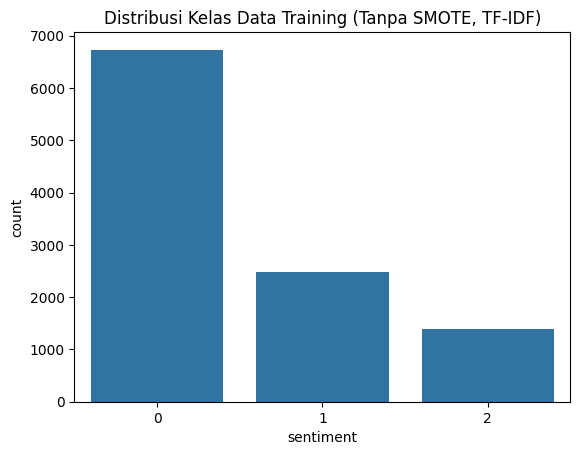

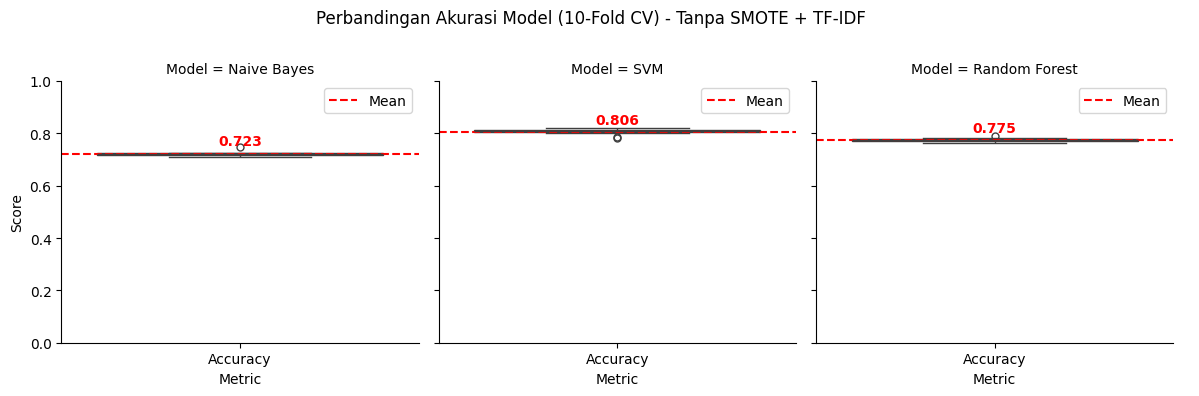

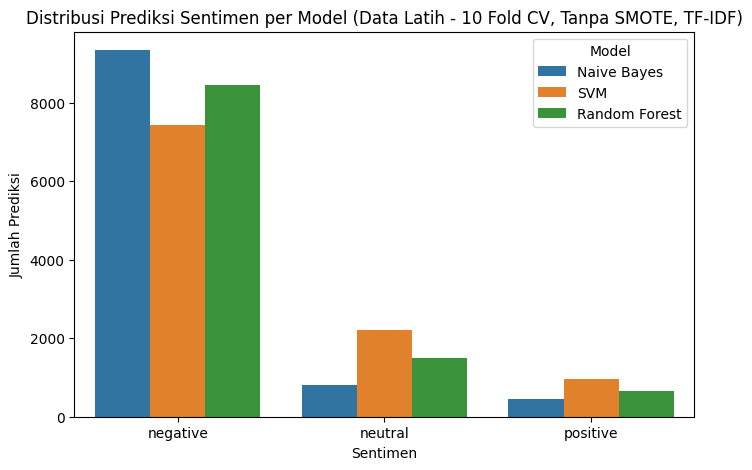


=== Hasil Akhir Naive Bayes (Tanpa SMOTE, TF-IDF) ===
Akurasi : 0.7262
Presisi : 0.7326
Recall  : 0.7262
F1-Score: 0.6710
AUC     : 0.8405


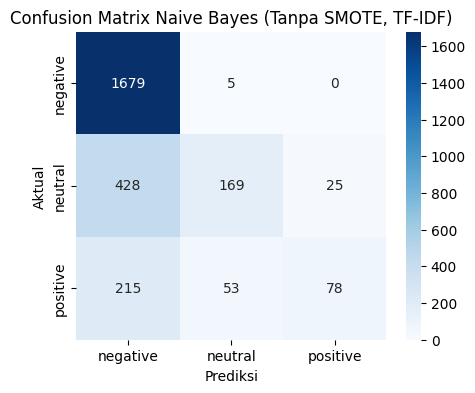

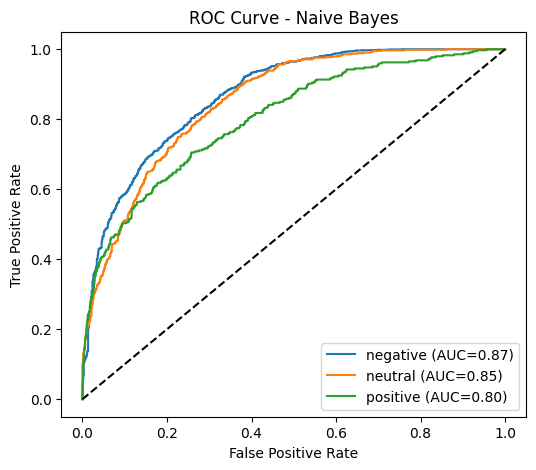


=== Hasil Akhir SVM (Tanpa SMOTE, TF-IDF) ===
Akurasi : 0.8096
Presisi : 0.8016
Recall  : 0.8096
F1-Score: 0.8017
AUC     : 0.9007


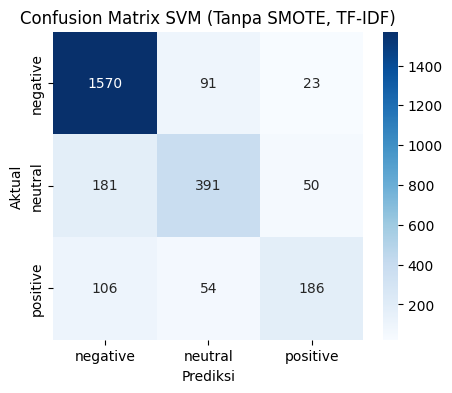

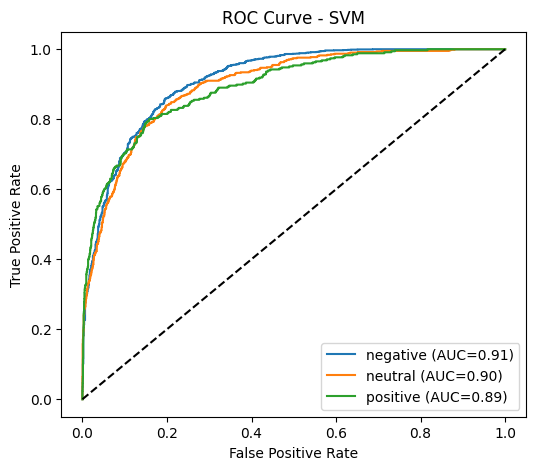


=== Hasil Akhir Random Forest (Tanpa SMOTE, TF-IDF) ===
Akurasi : 0.7760
Presisi : 0.7744
Recall  : 0.7760
F1-Score: 0.7519
AUC     : 0.8592


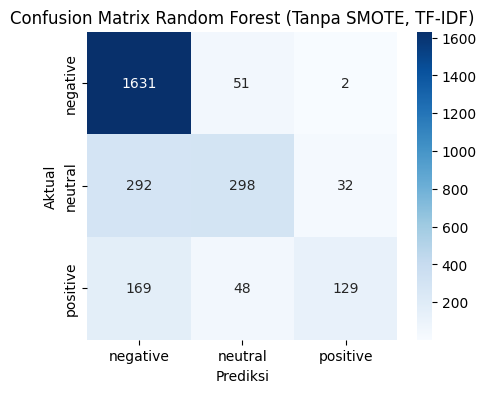

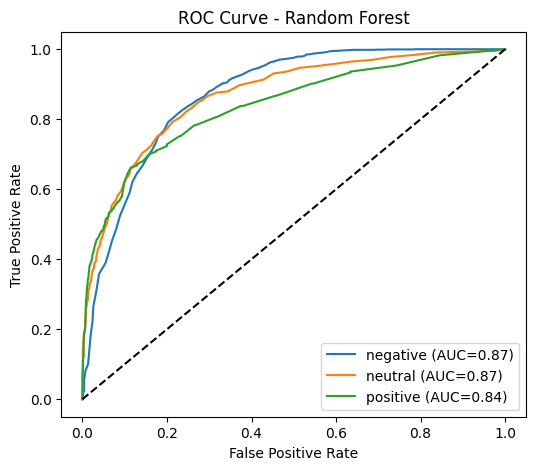

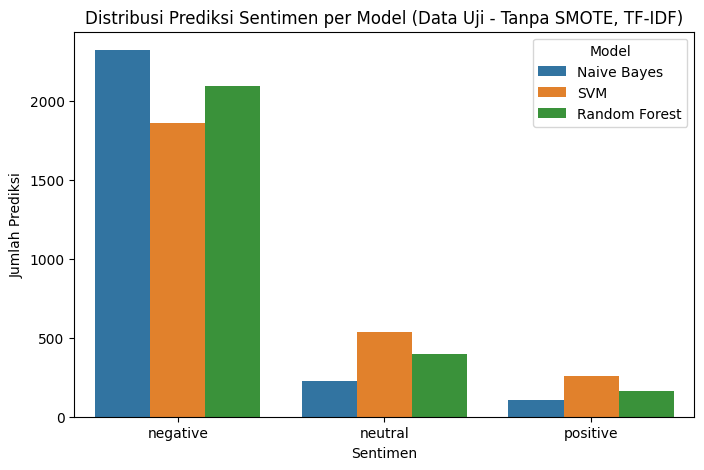

In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import joblib
import os

# ===== 2. Pengumpulan & Membaca Data =====
df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/labelrobertasudahconfidence.csv")

# ===== 3. Label Encoding =====
label_encoder = LabelEncoder()
df["sentiment"] = label_encoder.fit_transform(df["sentiment"])

# ===== 4. Pemisahan Dataset =====
X = df["clean_text"]
y = df["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===== 5. Ekstraksi Fitur (TF-IDF) =====
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_text)  # Fit + transform di training
X_test_vec = vectorizer.transform(X_test_text)        # Transform saja di testing

# ===== 6. Analisis Distribusi Kelas =====
sns.countplot(x=y_train)
plt.title("Distribusi Kelas Data Training (Tanpa SMOTE, TF-IDF)")
plt.show()

# ===== 7. Definisi Model =====
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# ===== 8. K-Fold Cross Validation (Tanpa SMOTE, TF-IDF) =====
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {model_name: {"Accuracy": []} for model_name in models}
train_pred_dist = []

for model_name, model in models.items():
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_vec, y_train), 1):
        # Split fold
        X_train_fold, X_val_fold = X_train_vec[train_idx], X_train_vec[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Fit model langsung tanpa SMOTE
        model.fit(X_train_fold, y_train_fold)

        # Prediksi pada validation fold
        y_pred = model.predict(X_val_fold)

        # Simpan metrik (hanya akurasi)
        cv_results[model_name]["Accuracy"].append(accuracy_score(y_val_fold, y_pred))

        # Simpan distribusi prediksi tiap fold
        unique, counts = np.unique(y_pred, return_counts=True)
        for cls, count in zip(unique, counts):
            train_pred_dist.append({
                "Model": model_name,
                "Fold": fold,
                "Sentimen": label_encoder.inverse_transform([cls])[0],
                "Jumlah": count
            })

# ===== 9. Ubah ke Format Long untuk Boxplot =====
plot_data = []
for model_name, metrics_dict in cv_results.items():
    for metric_name, scores in metrics_dict.items():
        for score in scores:
            plot_data.append({
                "Model": model_name,
                "Metric": metric_name,
                "Score": score
            })

cv_df = pd.DataFrame(plot_data)

# ===== 10. Visualisasi Boxplot (Hanya Akurasi CV) =====
g = sns.catplot(
    data=cv_df, x="Metric", y="Score", col="Model",
    kind="box", height=4, aspect=1
)
g.set(ylim=(0, 1))
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Perbandingan Akurasi Model (10-Fold CV) - Tanpa SMOTE + TF-IDF")

# Tambahkan garis mean + anotasi angka
for ax, model_name in zip(g.axes.flat, cv_df["Model"].unique()):
    mean_val = cv_df[cv_df["Model"] == model_name]["Score"].mean()
    # Garis rata-rata
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean")
    # Angka rata-rata
    ax.text(0, mean_val + 0.02, f"{mean_val:.3f}",
            ha="center", va="bottom", color="red", fontsize=10, weight="bold")
    ax.legend()

plt.show()

# ===== 11. Visualisasi Grouped Bar Chart Distribusi Prediksi (Data Latih via CV) =====
train_pred_df = pd.DataFrame(train_pred_dist)

plt.figure(figsize=(8, 5))
sns.barplot(data=train_pred_df, x="Sentimen", y="Jumlah", hue="Model", estimator=sum, errorbar=None)
plt.title("Distribusi Prediksi Sentimen per Model (Data Latih - 10 Fold CV, Tanpa SMOTE, TF-IDF)")
plt.ylabel("Jumlah Prediksi")
plt.xlabel("Sentimen")
plt.legend(title="Model")
plt.show()

# ===== 12. Pelatihan Akhir & Pengujian =====
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# Penampung distribusi prediksi data uji
test_pred_dist = []

for model_name, model in models.items():
    # Fit langsung tanpa SMOTE
    model.fit(X_train_vec, y_train)
    y_pred_test = model.predict(X_test_vec)

    # ===== Simpan distribusi prediksi data uji =====
    unique, counts = np.unique(y_pred_test, return_counts=True)
    for cls, count in zip(unique, counts):
        test_pred_dist.append({
            "Model": model_name,
            "Sentimen": label_encoder.inverse_transform([cls])[0],
            "Jumlah": count
        })

    # ===== Probabilitas / Decision Score =====
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_vec)
    else:  # LinearSVC
        y_score = model.decision_function(X_test_vec)

    # ===== Hitung AUC Macro OVR =====
    auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")

    print(f"\n=== Hasil Akhir {model_name} (Tanpa SMOTE, TF-IDF) ===")
    print(f"Akurasi : {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"Presisi : {precision_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"Recall  : {recall_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"AUC     : {auc_score:.4f}")

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix {model_name} (Tanpa SMOTE, TF-IDF)")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.show()

    # ===== ROC Curve (Opsional, Multi-class) =====
    plt.figure(figsize=(6, 5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()

# ===== 13. Visualisasi Grouped Bar Chart Distribusi Prediksi (Data Uji) =====
test_pred_df = pd.DataFrame(test_pred_dist)

plt.figure(figsize=(8, 5))
sns.barplot(data=test_pred_df, x="Sentimen", y="Jumlah", hue="Model", estimator=sum, errorbar=None)
plt.title("Distribusi Prediksi Sentimen per Model (Data Uji - Tanpa SMOTE, TF-IDF)")
plt.ylabel("Jumlah Prediksi")
plt.xlabel("Sentimen")
plt.legend(title="Model")
plt.show()

# PROSES SMOTE SKENARIO (DATA LEAKAGE)

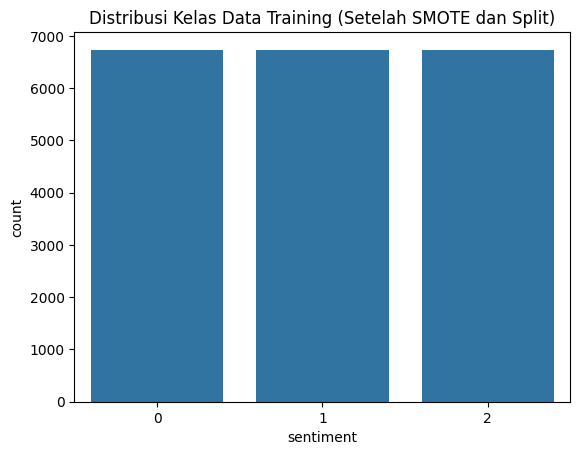

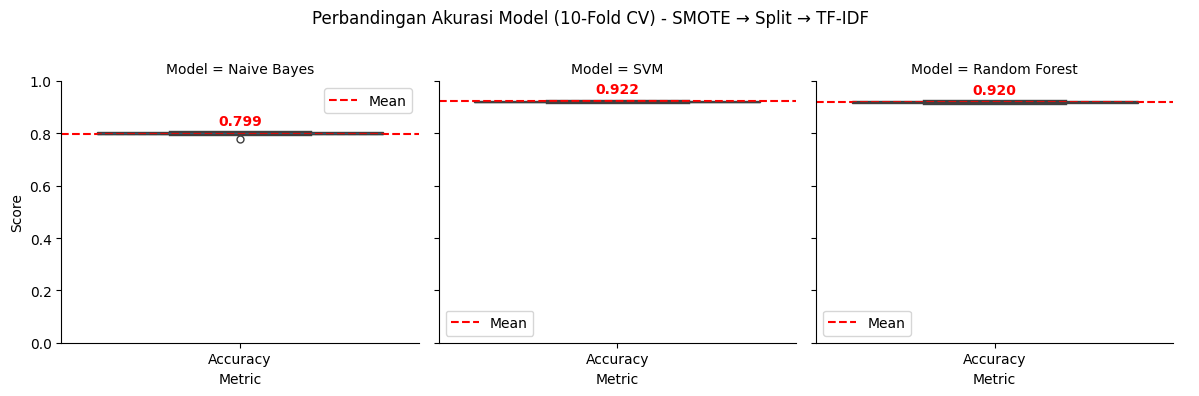

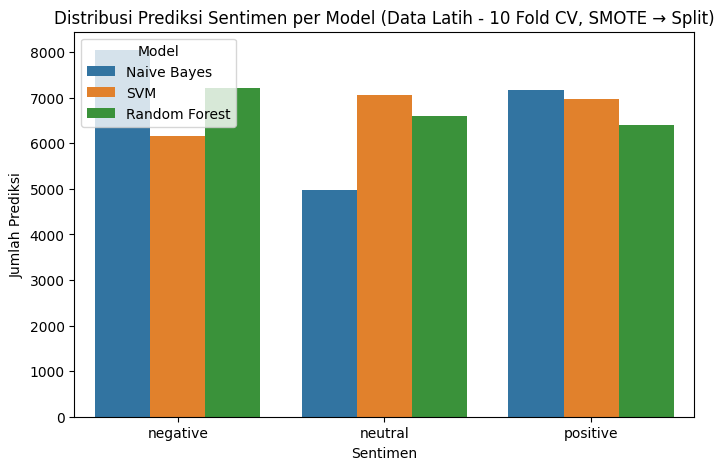


=== Hasil Akhir Naive Bayes ===
Akurasi : 0.8014
Presisi : 0.8099
Recall  : 0.8014
F1-Score: 0.7985
AUC     : 0.9469

Classification Report per Sentimen:
              precision    recall  f1-score   support

    negative       0.75      0.89      0.81      1683
     neutral       0.87      0.66      0.75      1684
    positive       0.80      0.86      0.83      1684

    accuracy                           0.80      5051
   macro avg       0.81      0.80      0.80      5051
weighted avg       0.81      0.80      0.80      5051



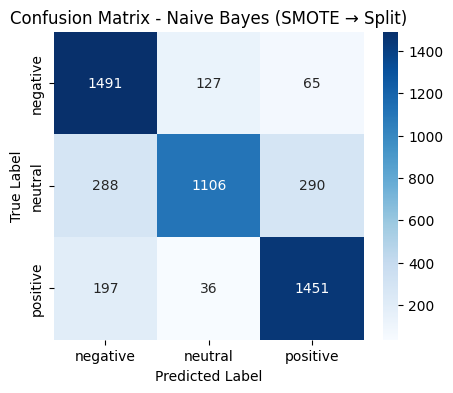

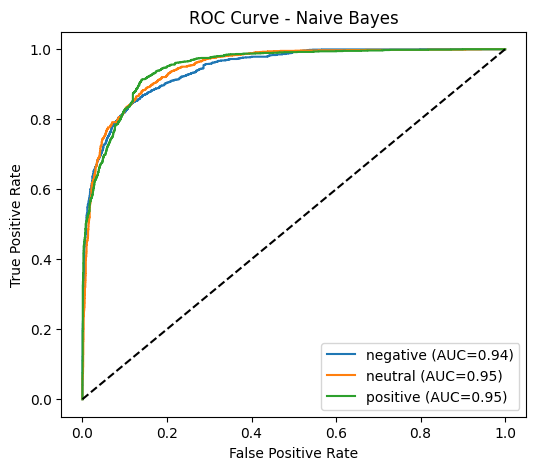

Model Naive Bayes berhasil disimpan ke /content/drive/MyDrive/Skripsi/Model/Naive_Bayes.h5

=== Hasil Akhir SVM ===
Akurasi : 0.9230
Presisi : 0.9245
Recall  : 0.9230
F1-Score: 0.9223
AUC     : 0.9852

Classification Report per Sentimen:
              precision    recall  f1-score   support

    negative       0.95      0.84      0.89      1683
     neutral       0.89      0.95      0.92      1684
    positive       0.94      0.97      0.96      1684

    accuracy                           0.92      5051
   macro avg       0.92      0.92      0.92      5051
weighted avg       0.92      0.92      0.92      5051



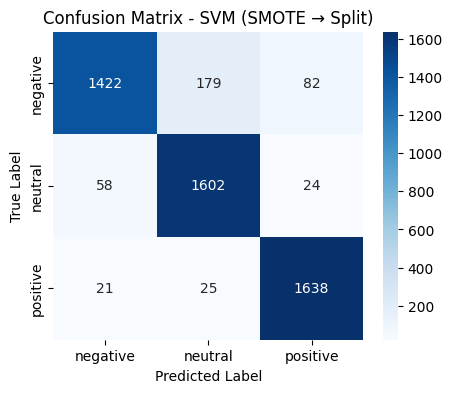

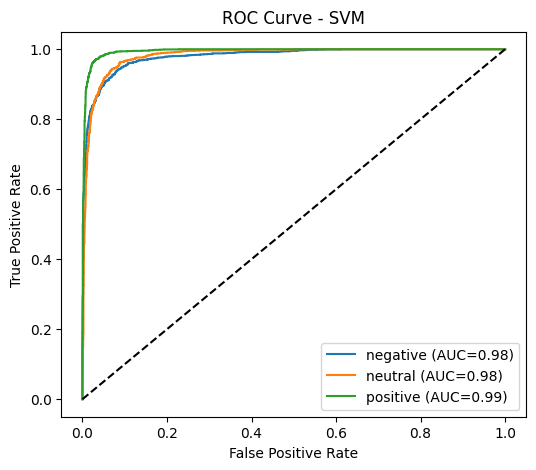

Model SVM berhasil disimpan ke /content/drive/MyDrive/Skripsi/Model/SVM.h5

=== Hasil Akhir Random Forest ===
Akurasi : 0.9254
Presisi : 0.9269
Recall  : 0.9254
F1-Score: 0.9257
AUC     : 0.9862

Classification Report per Sentimen:
              precision    recall  f1-score   support

    negative       0.88      0.93      0.90      1683
     neutral       0.92      0.90      0.91      1684
    positive       0.98      0.94      0.96      1684

    accuracy                           0.93      5051
   macro avg       0.93      0.93      0.93      5051
weighted avg       0.93      0.93      0.93      5051



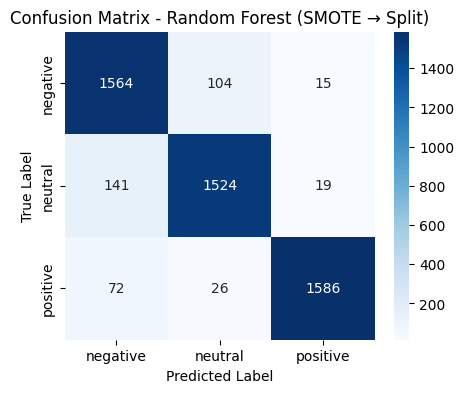

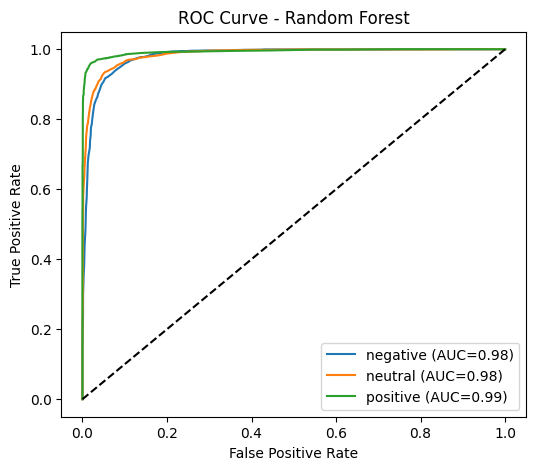

Model Random Forest berhasil disimpan ke /content/drive/MyDrive/Skripsi/Model/Random_Forest.h5


In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import h5py

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize

# ===== 2. Pengumpulan & Membaca Data =====
df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/labelrobertasudahconfidence.csv")

# ===== 3. Label Encoding =====
label_encoder = LabelEncoder()
df["sentiment"] = label_encoder.fit_transform(df["sentiment"])

# ===== 4. Pisahkan X & y =====
X = df["clean_text"]
y = df["sentiment"]

# ===== 5. Ekstraksi Fitur (TF-IDF di seluruh data) =====
vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(X)

# ===== 6. Terapkan SMOTE pada seluruh dataset =====
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_vec, y)

# ===== 7. Split Data Setelah SMOTE =====
X_train_vec, X_test_vec, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

# ===== 8. Analisis Distribusi Kelas =====
sns.countplot(x=y_train)
plt.title("Distribusi Kelas Data Training (Setelah SMOTE dan Split)")
plt.show()

# ===== 9. Definisi Model =====
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {model_name: {"Accuracy": [], "Precision": [], "Recall": [], "F1 Score": []}
              for model_name in models}
train_pred_dist = []

for model_name, model in models.items():
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_vec, y_train), 1):
        X_train_fold, X_val_fold = X_train_vec[train_idx], X_train_vec[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)

        cv_results[model_name]["Accuracy"].append(accuracy_score(y_val_fold, y_pred))
        cv_results[model_name]["Precision"].append(precision_score(y_val_fold, y_pred, average='weighted', zero_division=0))
        cv_results[model_name]["Recall"].append(recall_score(y_val_fold, y_pred, average='weighted', zero_division=0))
        cv_results[model_name]["F1 Score"].append(f1_score(y_val_fold, y_pred, average='weighted', zero_division=0))

        unique, counts = np.unique(y_pred, return_counts=True)
        for cls, count in zip(unique, counts):
            train_pred_dist.append({
                "Model": model_name,
                "Fold": fold,
                "Sentimen": label_encoder.inverse_transform([cls])[0],
                "Jumlah": count
            })

# ===== 10. Ubah ke Format Long untuk Boxplot (hanya Accuracy) =====
plot_data = []
for model_name, metrics_dict in cv_results.items():
    for score in metrics_dict["Accuracy"]:
        plot_data.append({
            "Model": model_name,
            "Metric": "Accuracy",
            "Score": score
        })

cv_df = pd.DataFrame(plot_data)

g = sns.catplot(
    data=cv_df, x="Metric", y="Score", col="Model",
    kind="box", height=4, aspect=1
)
g.set(ylim=(0, 1))
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Perbandingan Akurasi Model (10-Fold CV) - SMOTE → Split → TF-IDF")

for ax, model_name in zip(g.axes.flat, cv_df["Model"].unique()):
    mean_val = cv_df[cv_df["Model"] == model_name]["Score"].mean()
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean")
    ax.text(0, mean_val + 0.02, f"{mean_val:.3f}",
            ha="center", va="bottom", color="red", fontsize=10, weight="bold")
    ax.legend()

plt.show()

# ===== 11. Visualisasi Grouped Bar Chart Distribusi Prediksi (Data Latih via CV) =====
train_pred_df = pd.DataFrame(train_pred_dist)

plt.figure(figsize=(8, 5))
sns.barplot(data=train_pred_df, x="Sentimen", y="Jumlah", hue="Model", estimator=sum, errorbar=None)
plt.title("Distribusi Prediksi Sentimen per Model (Data Latih - 10 Fold CV, SMOTE → Split)")
plt.ylabel("Jumlah Prediksi")
plt.xlabel("Sentimen")
plt.legend(title="Model")
plt.show()

# ===== 12. Pelatihan Akhir & Pengujian =====
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred_test = model.predict(X_test_vec)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_vec)
    else:
        y_score = model.decision_function(X_test_vec)

    auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")

    print(f"\n=== Hasil Akhir {model_name} ===")
    print(f"Akurasi : {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"Presisi : {precision_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"Recall  : {recall_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"AUC     : {auc_score:.4f}")

    print("\nClassification Report per Sentimen:")
    print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {model_name} (SMOTE → Split)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    plt.figure(figsize=(6, 5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()

    # ===== 13. Simpan Model dalam format .h5 =====
    model_filename = f"/content/drive/MyDrive/Skripsi/Model/{model_name.replace(' ', '_')}.h5"

    # simpan model sklearn dengan joblib
    temp_pkl = model_filename.replace(".h5", ".pkl")
    joblib.dump(model, temp_pkl)

    # bungkus ke HDF5 (.h5)
    with h5py.File(model_filename, "w") as h5f:
        with open(temp_pkl, "rb") as f:
            binary_data = np.frombuffer(f.read(), dtype='uint8')
            h5f.create_dataset("sklearn_model", data=binary_data)

    print(f"Model {model_name} berhasil disimpan ke {model_filename}")


# Dengan Oversampling + TF-IDF

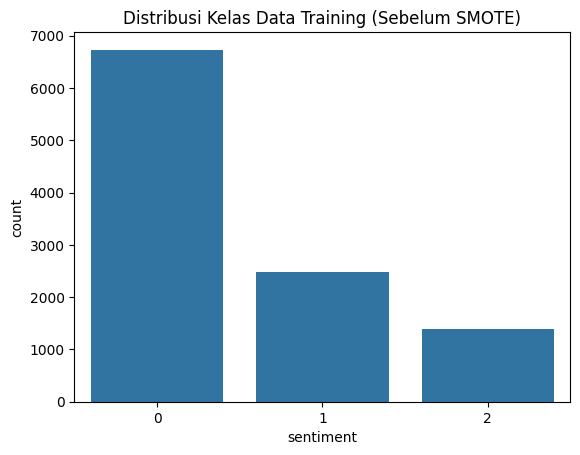

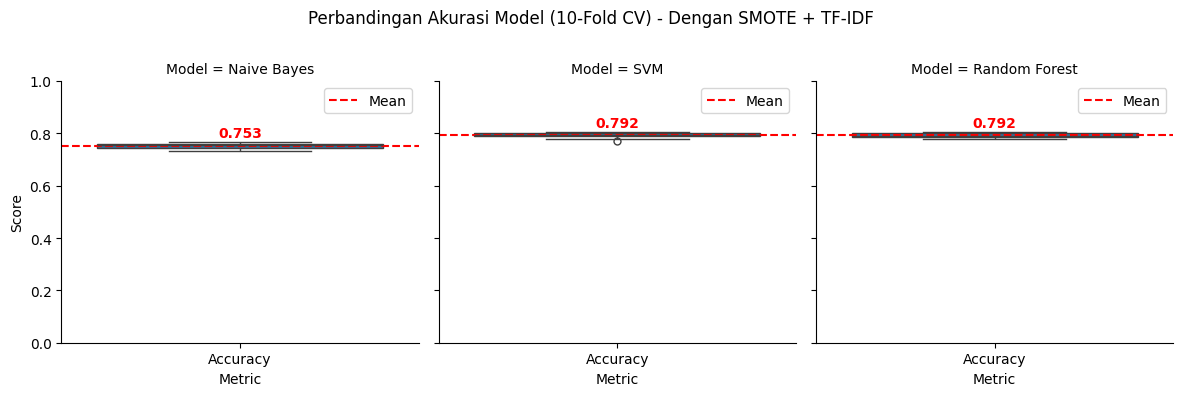

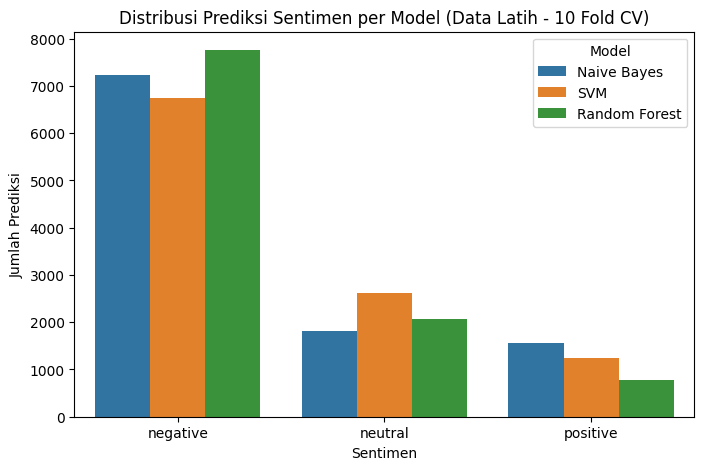


=== Hasil Akhir Naive Bayes ===
Akurasi : 0.7526
Presisi : 0.7479
Recall  : 0.7526
F1-Score: 0.7429
AUC     : 0.8570


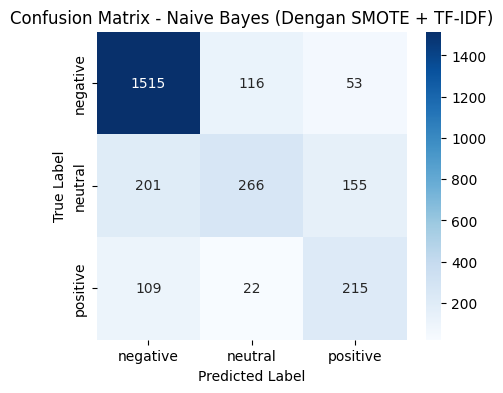

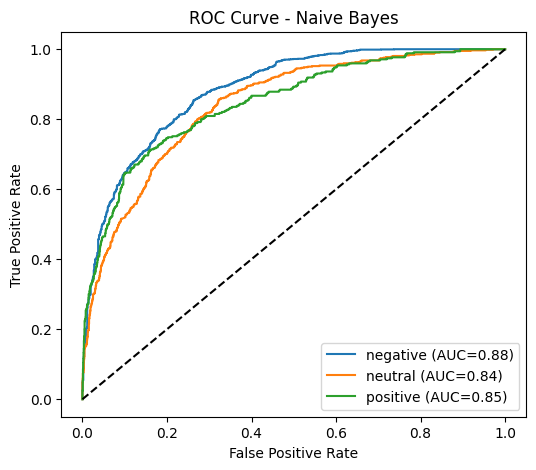


=== Hasil Akhir SVM ===
Akurasi : 0.7836
Presisi : 0.7836
Recall  : 0.7836
F1-Score: 0.7836
AUC     : 0.8925


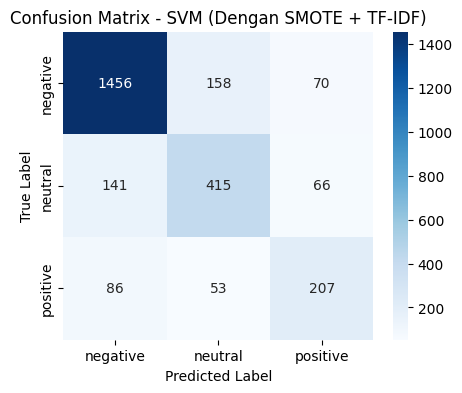

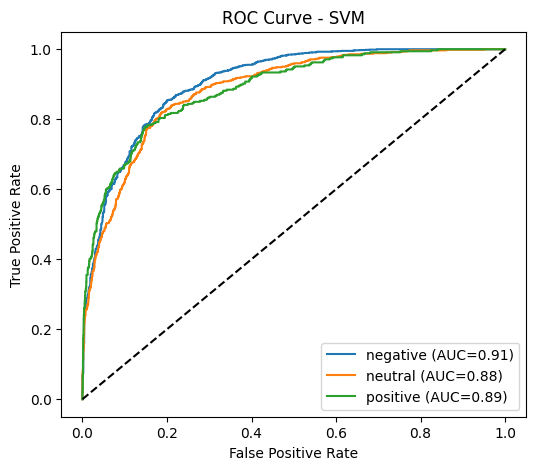


=== Hasil Akhir Random Forest ===
Akurasi : 0.7926
Presisi : 0.7869
Recall  : 0.7926
F1-Score: 0.7803
AUC     : 0.8728


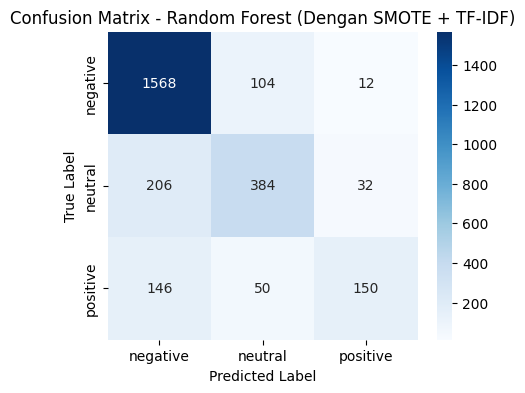

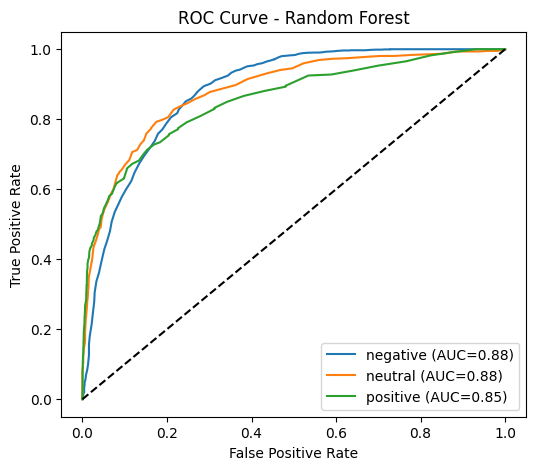

Model Naive Bayes disimpan di /content/drive/MyDrive/Skripsi/Model SMOTE Benar/naive_bayes_model.pkl
Model SVM disimpan di /content/drive/MyDrive/Skripsi/Model SMOTE Benar/svm_model.pkl
Model Random Forest disimpan di /content/drive/MyDrive/Skripsi/Model SMOTE Benar/random_forest_model.pkl


In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ===== 2. Pengumpulan & Membaca Data =====
df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/labelrobertasudahconfidence.csv")

# ===== 3. Label Encoding =====
label_encoder = LabelEncoder()
df["sentiment"] = label_encoder.fit_transform(df["sentiment"])

# ===== 4. Pemisahan Dataset =====
X = df["clean_text"]
y = df["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===== 5. Ekstraksi Fitur (TF-IDF) =====
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_text)  # Fit + transform di training
X_test_vec = vectorizer.transform(X_test_text)        # Transform saja di testing

# ===== 6. Analisis Distribusi Kelas =====
sns.countplot(x=y_train)
plt.title("Distribusi Kelas Data Training (Sebelum SMOTE)")
plt.show()


models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
smote = SMOTE(random_state=42)

cv_results = {model_name: {"Accuracy": [], "Precision": [], "Recall": [], "F1 Score": []}
              for model_name in models}
train_pred_dist = []

for model_name, model in models.items():
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_vec, y_train), 1):
        # Split fold
        X_train_fold, X_val_fold = X_train_vec[train_idx], X_train_vec[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Terapkan SMOTE hanya pada training fold
        X_train_res, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)

        # Fit model
        model.fit(X_train_res, y_train_res)

        # Prediksi pada validation fold (tanpa SMOTE)
        y_pred = model.predict(X_val_fold)

        # Simpan metrik
        cv_results[model_name]["Accuracy"].append(accuracy_score(y_val_fold, y_pred))
        cv_results[model_name]["Precision"].append(precision_score(y_val_fold, y_pred, average='weighted', zero_division=0))
        cv_results[model_name]["Recall"].append(recall_score(y_val_fold, y_pred, average='weighted', zero_division=0))
        cv_results[model_name]["F1 Score"].append(f1_score(y_val_fold, y_pred, average='weighted', zero_division=0))

        # Simpan distribusi prediksi tiap fold
        unique, counts = np.unique(y_pred, return_counts=True)
        for cls, count in zip(unique, counts):
            train_pred_dist.append({
                "Model": model_name,
                "Fold": fold,
                "Sentimen": label_encoder.inverse_transform([cls])[0],
                "Jumlah": count
            })

# ===== 9. Ubah ke Format Long untuk Boxplot (hanya Accuracy) =====
plot_data = []
for model_name, metrics_dict in cv_results.items():
    for score in metrics_dict["Accuracy"]:  # hanya ambil accuracy
        plot_data.append({
            "Model": model_name,
            "Metric": "Accuracy",
            "Score": score
        })

cv_df = pd.DataFrame(plot_data)

# ===== 10. Visualisasi Boxplot (Hanya Akurasi CV) =====
g = sns.catplot(
    data=cv_df, x="Metric", y="Score", col="Model",
    kind="box", height=4, aspect=1
)
g.set(ylim=(0, 1))
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Perbandingan Akurasi Model (10-Fold CV) - Dengan SMOTE + TF-IDF")

# Tambahkan garis mean + anotasi angka
for ax, model_name in zip(g.axes.flat, cv_df["Model"].unique()):
    mean_val = cv_df[cv_df["Model"] == model_name]["Score"].mean()
    # Garis rata-rata
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean")
    # Angka rata-rata
    ax.text(0, mean_val + 0.02, f"{mean_val:.3f}",
            ha="center", va="bottom", color="red", fontsize=10, weight="bold")
    ax.legend()

plt.show()


# ===== 11. Visualisasi Grouped Bar Chart Distribusi Prediksi (Data Latih via CV) =====
train_pred_df = pd.DataFrame(train_pred_dist)

plt.figure(figsize=(8, 5))
sns.barplot(data=train_pred_df, x="Sentimen", y="Jumlah", hue="Model", estimator=sum, errorbar=None)
plt.title("Distribusi Prediksi Sentimen per Model (Data Latih - 10 Fold CV)")
plt.ylabel("Jumlah Prediksi")
plt.xlabel("Sentimen")
plt.legend(title="Model")
plt.show()

# ===== 12. Pelatihan Akhir & Pengujian =====
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

for model_name, model in models.items():
    # Terapkan SMOTE di full training sebelum final fit
    X_train_res, y_train_res = smote.fit_resample(X_train_vec, y_train)

    model.fit(X_train_res, y_train_res)
    y_pred_test = model.predict(X_test_vec)

    # Ambil skor probabilitas atau decision function
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_vec)
    else:  # LinearSVC
        y_score = model.decision_function(X_test_vec)

    # Hitung AUC Macro OVR
    auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")

    print(f"\n=== Hasil Akhir {model_name} ===")
    print(f"Akurasi : {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"Presisi : {precision_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"Recall  : {recall_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"AUC     : {auc_score:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {model_name} (Dengan SMOTE + TF-IDF)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # ROC Curve per kelas
    plt.figure(figsize=(6, 5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()

# ===== 13. Simpan Model, Vectorizer, dan LabelEncoder =====
import joblib

# Simpan vectorizer (TF-IDF)
joblib.dump(vectorizer, "/content/drive/MyDrive/Skripsi/Model SMOTE Benar/feature_vectorizer.pkl")

# Simpan label encoder
joblib.dump(label_encoder, "/content/drive/MyDrive/Skripsi/Model SMOTE Benar/label_encoder.pkl")

# Simpan tiap model
for model_name, model in models.items():
    model_path = f"/content/drive/MyDrive/Skripsi/Model SMOTE Benar/{model_name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(model, model_path)
    print(f"Model {model_name} disimpan di {model_path}")


Label encoder berhasil dimuat dari file.

=== Evaluasi Naive Bayes di data20.csv ===
Akurasi : 0.6000
Presisi : 0.5778
Recall  : 0.6000
F1-Score: 0.5071
AUC     : 0.9084

Classification Report:
              precision    recall  f1-score   support

    negative       0.56      1.00      0.71        10
     neutral       1.00      0.33      0.50         6
    positive       0.00      0.00      0.00         4

    accuracy                           0.60        20
   macro avg       0.52      0.44      0.40        20
weighted avg       0.58      0.60      0.51        20



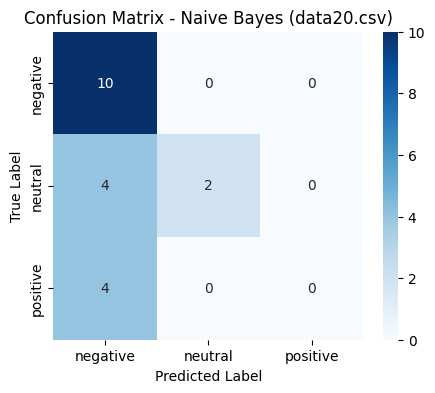


=== Evaluasi SVM di data20.csv ===
Akurasi : 0.8000
Presisi : 0.7991
Recall  : 0.8000
F1-Score: 0.7968
AUC     : 0.9341

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.90      0.86        10
     neutral       0.80      0.67      0.73         6
    positive       0.75      0.75      0.75         4

    accuracy                           0.80        20
   macro avg       0.79      0.77      0.78        20
weighted avg       0.80      0.80      0.80        20



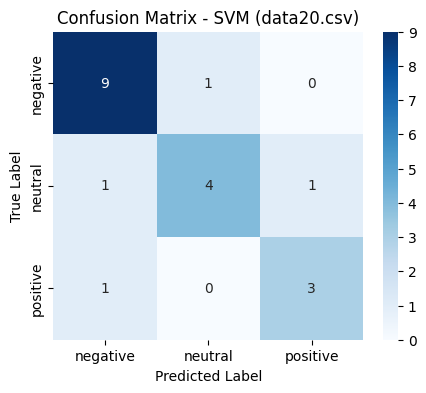


=== Evaluasi Random Forest di data20.csv ===
Akurasi : 0.8500
Presisi : 0.8846
Recall  : 0.8500
F1-Score: 0.8462
AUC     : 0.9863

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      1.00      0.87        10
     neutral       1.00      0.67      0.80         6
    positive       1.00      0.75      0.86         4

    accuracy                           0.85        20
   macro avg       0.92      0.81      0.84        20
weighted avg       0.88      0.85      0.85        20



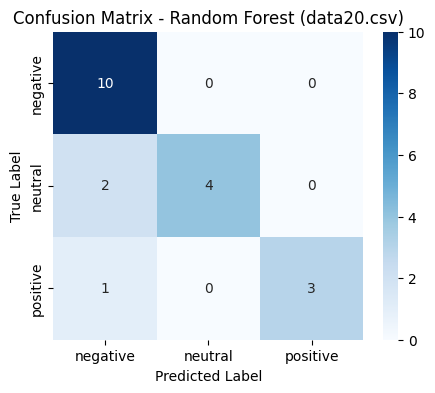

In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import numpy as np
import joblib
import h5py
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 2. Load Dataset Baru =====
df_new = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/20Roberta/20robertahasil.csv")

# Pastikan kolom sesuai
X_new = df_new["clean_text"]
y_true = df_new["sentiment"]   # label asli

# ===== 3. Load Vectorizer (hasil training sebelumnya) =====
vectorizer = joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/tfidf_vectorizer.pkl")
X_new_vec = vectorizer.transform(X_new)

# ===== 4. Fungsi Load Model dari .h5 (opsional) =====
def load_model_from_h5(h5_filename):
    with h5py.File(h5_filename, "r") as h5f:
        binary_data = h5f["sklearn_model"][:].tobytes()
    temp_pkl = h5_filename.replace(".h5", "_temp.pkl")
    with open(temp_pkl, "wb") as f:
        f.write(binary_data)
    model = joblib.load(temp_pkl)
    return model

# ===== 5. Load Semua Model =====
models = {
    "Naive Bayes": joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/naive_bayes.pkl"),
    "SVM": joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/svm.pkl"),
    "Random Forest": joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/random_forest.pkl"),
}

# ===== 6. Load LabelEncoder =====
try:
    label_encoder = joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/label_encoder.pkl")
    print("Label encoder berhasil dimuat dari file.")
except:
    print("⚠️ Tidak ditemukan label_encoder.pkl, membuat baru dari data20.csv (hati-hati: urutan kelas bisa beda dari training).")
    label_encoder = LabelEncoder()
    label_encoder.fit(y_true)

# ===== 7. Evaluasi Model di Dataset Baru =====
for model_name, model in models.items():
    y_pred = model.predict(X_new_vec)

    # Samakan tipe label
    if y_true.dtype == object and np.issubdtype(y_pred.dtype, np.number):
        y_true_enc = label_encoder.transform(y_true)
        y_pred_enc = y_pred
    elif np.issubdtype(y_true.dtype, np.number) and y_pred.dtype == object:
        y_true_enc = y_true
        y_pred_enc = label_encoder.transform(y_pred)
    else:
        y_true_enc, y_pred_enc = y_true, y_pred

    print(f"\n=== Evaluasi {model_name} di data20.csv ===")
    print(f"Akurasi : {accuracy_score(y_true_enc, y_pred_enc):.4f}")
    print(f"Presisi : {precision_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")
    print(f"Recall  : {recall_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")

    # ===== Hitung AUC jika memungkinkan =====
    try:
        # Binarisasi label true → one-vs-rest
        y_true_bin = label_binarize(y_true_enc, classes=np.arange(len(label_encoder.classes_)))

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_new_vec)
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_new_vec)
        else:
            y_score = None

        if y_score is not None:
            auc = roc_auc_score(y_true_bin, y_score, multi_class="ovr", average="macro")
            print(f"AUC     : {auc:.4f}")
        else:
            print("AUC     : ⚠️ Model tidak mendukung probabilitas.")
    except Exception as e:
        print(f"AUC     : Error menghitung AUC → {e}")

    # ===== Classification Report =====
    print("\nClassification Report:")
    print(classification_report(y_true_enc, y_pred_enc, zero_division=0, target_names=label_encoder.classes_))

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true_enc, y_pred_enc)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Confusion Matrix - {model_name} (data20.csv)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()



=== Hasil Akhir Naive Bayes ===
Akurasi : 0.7526
Presisi : 0.7479
Recall  : 0.7526
F1-Score: 0.7429
AUC     : 0.8570

Classification Report per Sentimen:
              precision    recall  f1-score   support

    negative       0.83      0.90      0.86      1684
     neutral       0.66      0.43      0.52       622
    positive       0.51      0.62      0.56       346

    accuracy                           0.75      2652
   macro avg       0.67      0.65      0.65      2652
weighted avg       0.75      0.75      0.74      2652



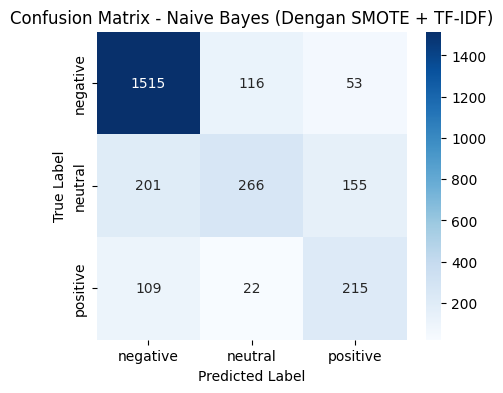

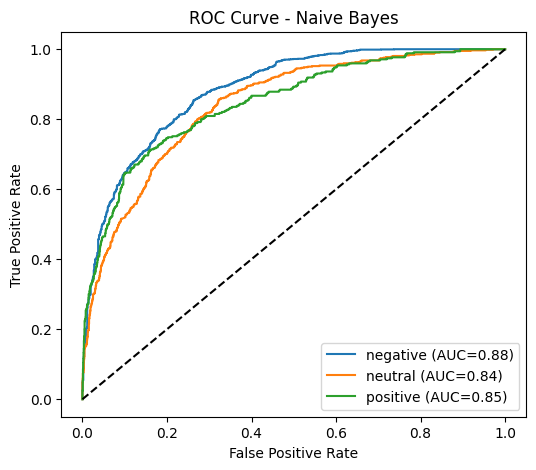


=== Hasil Akhir SVM ===
Akurasi : 0.7836
Presisi : 0.7836
Recall  : 0.7836
F1-Score: 0.7836
AUC     : 0.8925

Classification Report per Sentimen:
              precision    recall  f1-score   support

    negative       0.87      0.86      0.86      1684
     neutral       0.66      0.67      0.67       622
    positive       0.60      0.60      0.60       346

    accuracy                           0.78      2652
   macro avg       0.71      0.71      0.71      2652
weighted avg       0.78      0.78      0.78      2652



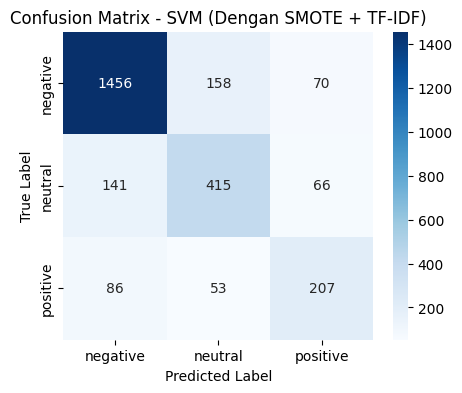

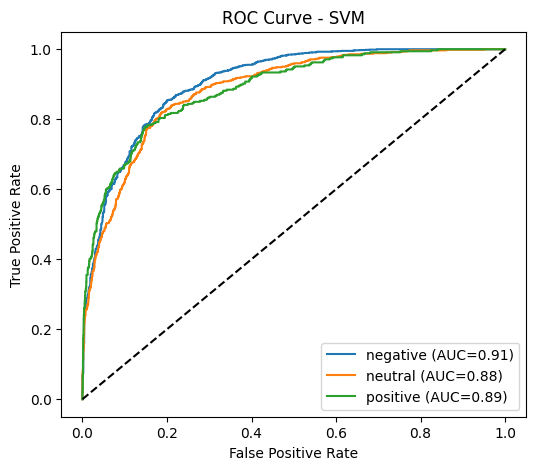


=== Hasil Akhir Random Forest ===
Akurasi : 0.7926
Presisi : 0.7869
Recall  : 0.7926
F1-Score: 0.7803
AUC     : 0.8728

Classification Report per Sentimen:
              precision    recall  f1-score   support

    negative       0.82      0.93      0.87      1684
     neutral       0.71      0.62      0.66       622
    positive       0.77      0.43      0.56       346

    accuracy                           0.79      2652
   macro avg       0.77      0.66      0.70      2652
weighted avg       0.79      0.79      0.78      2652



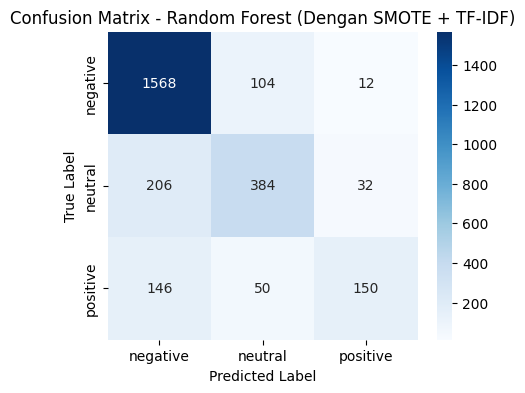

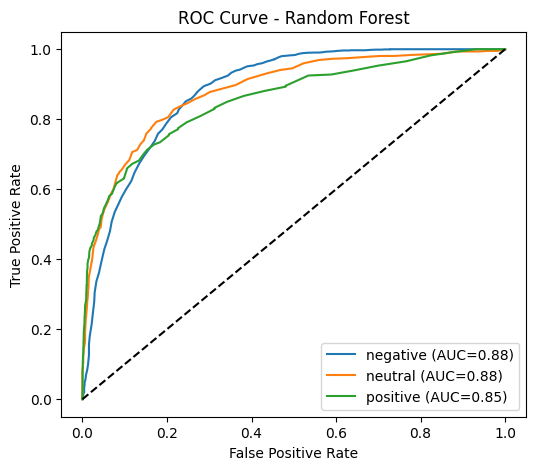

In [ ]:
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

for model_name, model in models.items():
    # Terapkan SMOTE di full training sebelum final fit
    X_train_res, y_train_res = smote.fit_resample(X_train_vec, y_train)

    model.fit(X_train_res, y_train_res)
    y_pred_test = model.predict(X_test_vec)

    # Ambil skor probabilitas atau decision function
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_vec)
    else:  # LinearSVC
        y_score = model.decision_function(X_test_vec)

    # Hitung AUC Macro OVR
    auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")

    print(f"\n=== Hasil Akhir {model_name} ===")
    print(f"Akurasi : {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"Presisi : {precision_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"Recall  : {recall_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}")
    print(f"AUC     : {auc_score:.4f}")

    # === Classification Report per Sentimen ===
    print("\nClassification Report per Sentimen:")
    print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {model_name} (Dengan SMOTE + TF-IDF)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # ROC Curve per kelas
    plt.figure(figsize=(6, 5))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()

                                          clean_text sentiment  confidence
0  [USER] jangan sampe danantara/mbg jadi kayak 1mdb  negative    0.998023
1  [USER] [USER] [USER] [USER] ingat bahwa pendir...  negative    0.961135
2  [USER] tolong kupas sekalian arti kunjungan pm...  negative    0.920569
3  [USER] efek danantara dan potensi bbri jadi sa...   neutral    0.993455
4  [USER] ntar aja lah klo danantara udah jelas a...  negative    0.995068


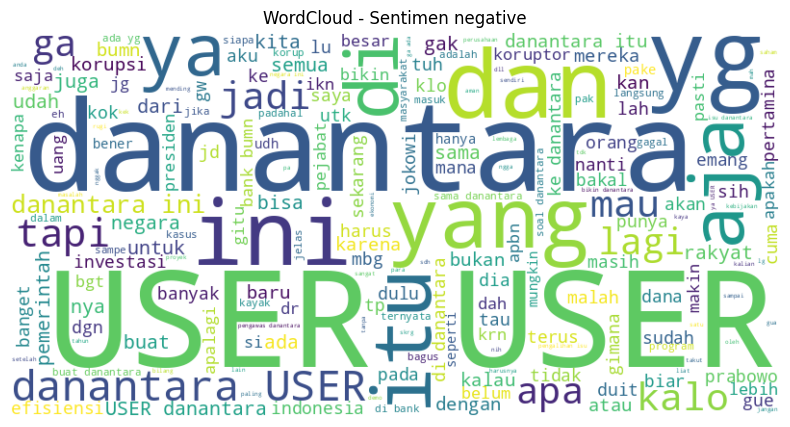

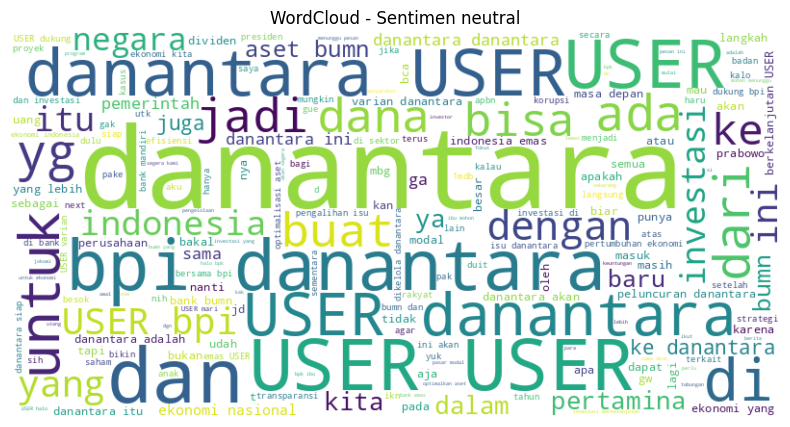

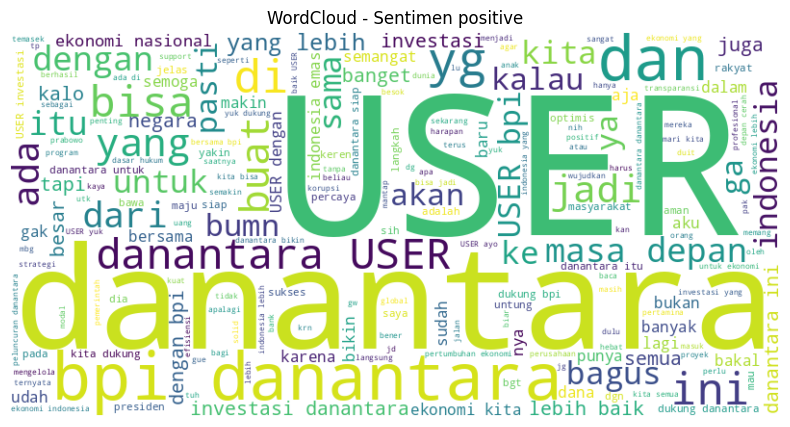

In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ===== 2. Load Data =====
df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/labelrobertasudahconfidence.csv")

# Pastikan ada kolom 'text' dan 'label'
print(df.head())

# ===== 3. Buat WordCloud per Sentimen =====
sentimen = df['sentiment'].unique()

for s in sentimen:
    text = " ".join(df[df['sentiment'] == s]['clean_text'].astype(str))

    wc = WordCloud(width=800, height=400,
                   background_color="white",
                   colormap="viridis",
                   max_words=200).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - Sentimen {s}")
    plt.show()


# HASIL ANALISIS

In [ ]:
import pandas as pd
import joblib
from IPython.display import display

# ===== 1. Load Dataset Baru =====
df_new = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/20Roberta/robertahasil150siapmodel.csv")
X_new = df_new["clean_text"]
y_true = df_new["sentiment"]   # label asli (jika ada)

# ===== 2. Definisi Skenario =====
scenarios = {
    "Tanpa SMOTE": "/content/drive/MyDrive/Skripsi/Tanpa_SMOTE",
    "SMOTE Data Latih": "/content/drive/MyDrive/Skripsi/SMOTE_Latih",
    "SMOTE Seluruh Data": "/content/drive/MyDrive/Skripsi/SMOTE_Full"
}

# ===== 3. Tabel Hasil =====
results = []

for scenario_name, base_path in scenarios.items():
    # Load vectorizer & encoder khusus skenario ini
    vectorizer = joblib.load(f"{base_path}/tfidf_vectorizer.pkl")
    label_encoder = joblib.load(f"{base_path}/label_encoder.pkl")

    X_new_vec = vectorizer.transform(X_new)

    # Load semua model di skenario ini
    models = {
        "Naive Bayes": joblib.load(f"{base_path}/naive_bayes.pkl"),
        "Support Vector Machine": joblib.load(f"{base_path}/svm.pkl"),
        "Random Forest": joblib.load(f"{base_path}/random_forest.pkl"),
    }

    for i, text in enumerate(X_new):
        row = {
            "No": i+1,
            "Post": text,
            "Skenario": scenario_name
        }
        for model_name, model in models.items():
            pred = model.predict(X_new_vec[i])
            pred_label = label_encoder.inverse_transform(pred)[0]
            row[model_name] = pred_label
        # Tambahkan label asli kalau ada
        row["Label Sentimen"] = y_true.iloc[i] if y_true is not None else "-"
        results.append(row)

# ===== 4. Buat DataFrame Hasil =====
df_results = pd.DataFrame(results)

# ===== 5. Tampilkan langsung =====
display(df_results.head(1000))


,No,Post,Skenario,Naive Bayes,Support Vector Machine,Random Forest,Label Sentimen
0,1,[USER] presiden prabowo emang nggak setengahse...,Tanpa SMOTE,negative,negative,positive,positive
1,2,[USER] presiden prabowo pun percaya danantara ...,Tanpa SMOTE,negative,positive,positive,positive
2,3,[USER] langkah presiden prabowo dukung dananta...,Tanpa SMOTE,neutral,positive,positive,positive
3,4,[USER] dukung nyata presiden prabowo ke danant...,Tanpa SMOTE,negative,positive,positive,positive
4,5,[USER] presiden prabowo kasih peluang lebih be...,Tanpa SMOTE,negative,positive,positive,neutral
...,...,...,...,...,...,...,...
442,145,[USER] solusi ai hilir mbg danantara,SMOTE Seluruh Data,neutral,neutral,neutral,neutral
443,146,danantara bukan sekadar kelola asetini motor g...,SMOTE Seluruh Data,positive,neutral,neutral,positive
444,147,dengan konsolidasi aset dan investasi cerdas d...,SMOTE Seluruh Data,positive,positive,neutral,positive
445,148,energi baru teknologi hilirisasidanantara doro...,SMOTE Seluruh Data,positive,neutral,neutral,neutral


# HASIL DATA20.CSV

Label encoder berhasil dimuat dari file.

=== Evaluasi Naive Bayes di data20.csv ===
Akurasi : 0.6000
Presisi : 0.5778
Recall  : 0.6000
F1-Score: 0.5071
AUC     : 0.9084

Classification Report:
              precision    recall  f1-score   support

    negative       0.56      1.00      0.71        10
     neutral       1.00      0.33      0.50         6
    positive       0.00      0.00      0.00         4

    accuracy                           0.60        20
   macro avg       0.52      0.44      0.40        20
weighted avg       0.58      0.60      0.51        20



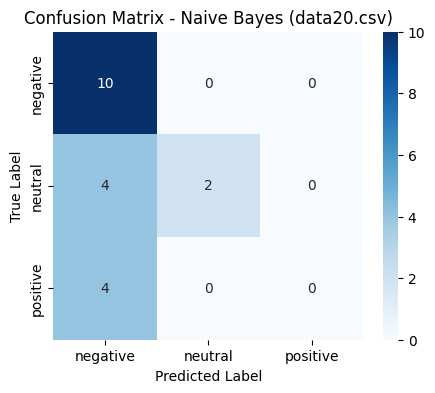


=== Evaluasi SVM di data20.csv ===
Akurasi : 0.8000
Presisi : 0.7991
Recall  : 0.8000
F1-Score: 0.7968
AUC     : 0.9341

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.90      0.86        10
     neutral       0.80      0.67      0.73         6
    positive       0.75      0.75      0.75         4

    accuracy                           0.80        20
   macro avg       0.79      0.77      0.78        20
weighted avg       0.80      0.80      0.80        20



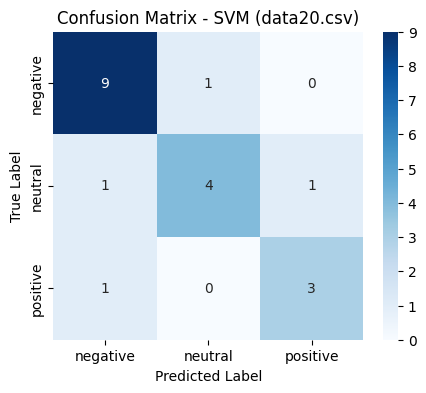


=== Evaluasi Random Forest di data20.csv ===
Akurasi : 0.8500
Presisi : 0.8846
Recall  : 0.8500
F1-Score: 0.8462
AUC     : 0.9863

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      1.00      0.87        10
     neutral       1.00      0.67      0.80         6
    positive       1.00      0.75      0.86         4

    accuracy                           0.85        20
   macro avg       0.92      0.81      0.84        20
weighted avg       0.88      0.85      0.85        20



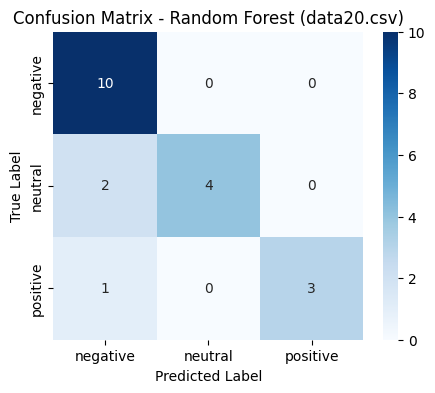

In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import numpy as np
import joblib
import h5py
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 2. Load Dataset Baru =====
df_new = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/20Roberta/20robertahasil.csv")

# Pastikan kolom sesuai
X_new = df_new["clean_text"]
y_true = df_new["sentiment"]   # label asli

# ===== 3. Load Vectorizer (hasil training sebelumnya) =====
vectorizer = joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/tfidf_vectorizer.pkl")
X_new_vec = vectorizer.transform(X_new)

# ===== 4. Fungsi Load Model dari .h5 (opsional) =====
def load_model_from_h5(h5_filename):
    with h5py.File(h5_filename, "r") as h5f:
        binary_data = h5f["sklearn_model"][:].tobytes()
    temp_pkl = h5_filename.replace(".h5", "_temp.pkl")
    with open(temp_pkl, "wb") as f:
        f.write(binary_data)
    model = joblib.load(temp_pkl)
    return model

# ===== 5. Load Semua Model =====
models = {
    "Naive Bayes": joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/naive_bayes.pkl"),
    "SVM": joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/svm.pkl"),
    "Random Forest": joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/random_forest.pkl"),
}

# ===== 6. Load LabelEncoder =====
try:
    label_encoder = joblib.load("/content/drive/MyDrive/Skripsi/Tanpa_SMOTE/label_encoder.pkl")
    print("Label encoder berhasil dimuat dari file.")
except:
    print("⚠️ Tidak ditemukan label_encoder.pkl, membuat baru dari data20.csv (hati-hati: urutan kelas bisa beda dari training).")
    label_encoder = LabelEncoder()
    label_encoder.fit(y_true)

# ===== 7. Evaluasi Model di Dataset Baru =====
for model_name, model in models.items():
    y_pred = model.predict(X_new_vec)

    # Samakan tipe label
    if y_true.dtype == object and np.issubdtype(y_pred.dtype, np.number):
        y_true_enc = label_encoder.transform(y_true)
        y_pred_enc = y_pred
    elif np.issubdtype(y_true.dtype, np.number) and y_pred.dtype == object:
        y_true_enc = y_true
        y_pred_enc = label_encoder.transform(y_pred)
    else:
        y_true_enc, y_pred_enc = y_true, y_pred

    print(f"\n=== Evaluasi {model_name} di data20.csv ===")
    print(f"Akurasi : {accuracy_score(y_true_enc, y_pred_enc):.4f}")
    print(f"Presisi : {precision_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")
    print(f"Recall  : {recall_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")

    # ===== Hitung AUC jika memungkinkan =====
    try:
        # Binarisasi label true → one-vs-rest
        y_true_bin = label_binarize(y_true_enc, classes=np.arange(len(label_encoder.classes_)))

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_new_vec)
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_new_vec)
        else:
            y_score = None

        if y_score is not None:
            auc = roc_auc_score(y_true_bin, y_score, multi_class="ovr", average="macro")
            print(f"AUC     : {auc:.4f}")
        else:
            print("AUC     : ⚠️ Model tidak mendukung probabilitas.")
    except Exception as e:
        print(f"AUC     : Error menghitung AUC → {e}")

    # ===== Classification Report =====
    print("\nClassification Report:")
    print(classification_report(y_true_enc, y_pred_enc, zero_division=0, target_names=label_encoder.classes_))

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true_enc, y_pred_enc)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Confusion Matrix - {model_name} (data20.csv)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


Label encoder berhasil dimuat dari file.

=== Evaluasi Naive Bayes di data20.csv ===
Akurasi : 0.7000
Presisi : 0.7000
Recall  : 0.7000
F1-Score: 0.6583
AUC     : 0.9298

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.90      0.90        10
     neutral       0.50      0.17      0.25         6
    positive       0.50      1.00      0.67         4

    accuracy                           0.70        20
   macro avg       0.63      0.69      0.61        20
weighted avg       0.70      0.70      0.66        20



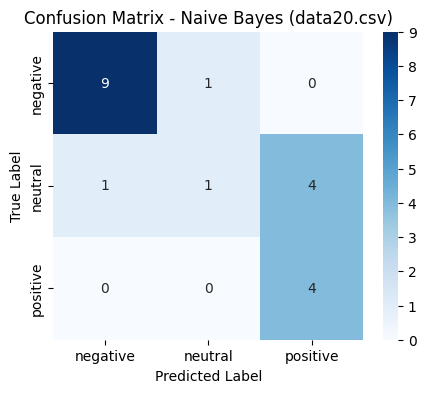


=== Evaluasi SVM di data20.csv ===
Akurasi : 0.7500
Presisi : 0.7541
Recall  : 0.7500
F1-Score: 0.7419
AUC     : 0.9088

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.90      0.86        10
     neutral       0.75      0.50      0.60         6
    positive       0.60      0.75      0.67         4

    accuracy                           0.75        20
   macro avg       0.72      0.72      0.71        20
weighted avg       0.75      0.75      0.74        20



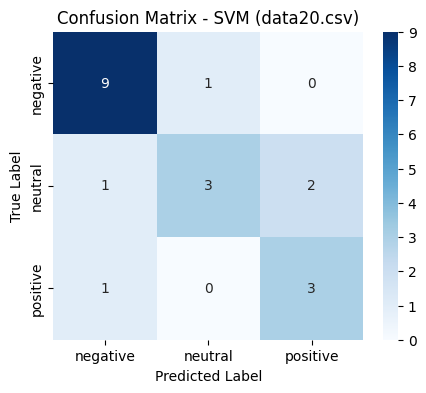


=== Evaluasi Random Forest di data20.csv ===
Akurasi : 0.9500
Presisi : 0.9545
Recall  : 0.9500
F1-Score: 0.9476
AUC     : 0.9896

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      1.00      0.95        10
     neutral       1.00      1.00      1.00         6
    positive       1.00      0.75      0.86         4

    accuracy                           0.95        20
   macro avg       0.97      0.92      0.94        20
weighted avg       0.95      0.95      0.95        20



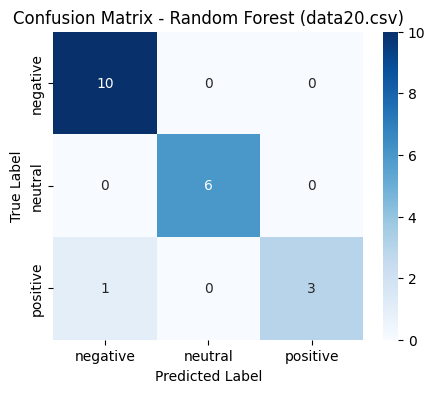

In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import numpy as np
import joblib
import h5py
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 2. Load Dataset Baru =====
df_new = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/20Roberta/20robertahasil.csv")

# Pastikan kolom sesuai
X_new = df_new["clean_text"]
y_true = df_new["sentiment"]   # label asli

# ===== 3. Load Vectorizer (hasil training sebelumnya) =====
vectorizer = joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Latih/tfidf_vectorizer.pkl")
X_new_vec = vectorizer.transform(X_new)

# ===== 4. Fungsi Load Model dari .h5 (opsional) =====
def load_model_from_h5(h5_filename):
    with h5py.File(h5_filename, "r") as h5f:
        binary_data = h5f["sklearn_model"][:].tobytes()
    temp_pkl = h5_filename.replace(".h5", "_temp.pkl")
    with open(temp_pkl, "wb") as f:
        f.write(binary_data)
    model = joblib.load(temp_pkl)
    return model

# ===== 5. Load Semua Model =====
models = {
    "Naive Bayes": joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Latih/naive_bayes.pkl"),
    "SVM": joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Latih/svm.pkl"),
    "Random Forest": joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Latih/random_forest.pkl"),
}

# ===== 6. Load LabelEncoder =====
try:
    label_encoder = joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Latih/label_encoder.pkl")
    print("Label encoder berhasil dimuat dari file.")
except:
    print("⚠️ Tidak ditemukan label_encoder.pkl, membuat baru dari data20.csv (hati-hati: urutan kelas bisa beda dari training).")
    label_encoder = LabelEncoder()
    label_encoder.fit(y_true)

# ===== 7. Evaluasi Model di Dataset Baru =====
for model_name, model in models.items():
    y_pred = model.predict(X_new_vec)

    # Samakan tipe label
    if y_true.dtype == object and np.issubdtype(y_pred.dtype, np.number):
        y_true_enc = label_encoder.transform(y_true)
        y_pred_enc = y_pred
    elif np.issubdtype(y_true.dtype, np.number) and y_pred.dtype == object:
        y_true_enc = y_true
        y_pred_enc = label_encoder.transform(y_pred)
    else:
        y_true_enc, y_pred_enc = y_true, y_pred

    print(f"\n=== Evaluasi {model_name} di data20.csv ===")
    print(f"Akurasi : {accuracy_score(y_true_enc, y_pred_enc):.4f}")
    print(f"Presisi : {precision_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")
    print(f"Recall  : {recall_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")

    # ===== Hitung AUC jika memungkinkan =====
    try:
        # Binarisasi label true → one-vs-rest
        y_true_bin = label_binarize(y_true_enc, classes=np.arange(len(label_encoder.classes_)))

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_new_vec)
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_new_vec)
        else:
            y_score = None

        if y_score is not None:
            auc = roc_auc_score(y_true_bin, y_score, multi_class="ovr", average="macro")
            print(f"AUC     : {auc:.4f}")
        else:
            print("AUC     : ⚠️ Model tidak mendukung probabilitas.")
    except Exception as e:
        print(f"AUC     : Error menghitung AUC → {e}")

    # ===== Classification Report =====
    print("\nClassification Report:")
    print(classification_report(y_true_enc, y_pred_enc, zero_division=0, target_names=label_encoder.classes_))

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true_enc, y_pred_enc)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Confusion Matrix - {model_name} (data20.csv)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


Label encoder berhasil dimuat dari file.

=== Evaluasi Naive Bayes di data20.csv ===
Akurasi : 0.7500
Presisi : 0.7424
Recall  : 0.7500
F1-Score: 0.7219
AUC     : 0.9457

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.90      0.86        10
     neutral       0.67      0.33      0.44         6
    positive       0.67      1.00      0.80         4

    accuracy                           0.75        20
   macro avg       0.72      0.74      0.70        20
weighted avg       0.74      0.75      0.72        20



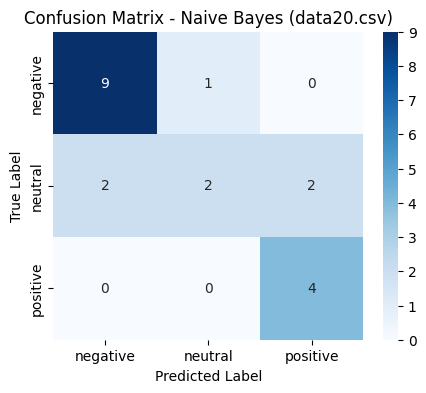


=== Evaluasi SVM di data20.csv ===
Akurasi : 0.8000
Presisi : 0.8367
Recall  : 0.8000
F1-Score: 0.7879
AUC     : 0.9313

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      1.00      0.91        10
     neutral       1.00      0.50      0.67         6
    positive       0.60      0.75      0.67         4

    accuracy                           0.80        20
   macro avg       0.81      0.75      0.75        20
weighted avg       0.84      0.80      0.79        20



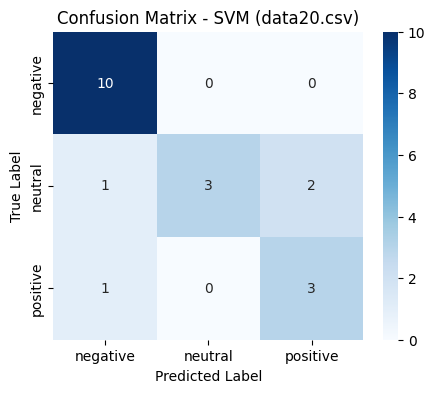


=== Evaluasi Random Forest di data20.csv ===
Akurasi : 0.9000
Presisi : 0.9167
Recall  : 0.9000
F1-Score: 0.8987
AUC     : 0.9921

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      1.00      0.91        10
     neutral       1.00      0.83      0.91         6
    positive       1.00      0.75      0.86         4

    accuracy                           0.90        20
   macro avg       0.94      0.86      0.89        20
weighted avg       0.92      0.90      0.90        20



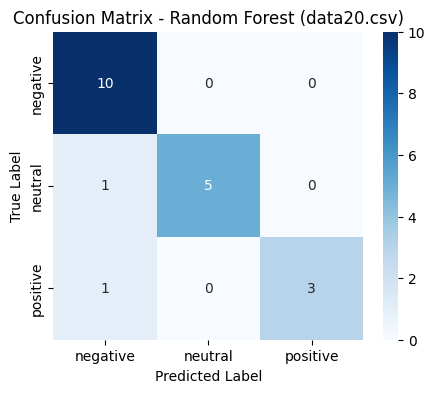

In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import numpy as np
import joblib
import h5py
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 2. Load Dataset Baru =====
df_new = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/20Roberta/20robertahasil.csv")

# Pastikan kolom sesuai
X_new = df_new["clean_text"]
y_true = df_new["sentiment"]   # label asli

# ===== 3. Load Vectorizer (hasil training sebelumnya) =====
vectorizer = joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Full/tfidf_vectorizer.pkl")
X_new_vec = vectorizer.transform(X_new)

# ===== 4. Fungsi Load Model dari .h5 (opsional) =====
def load_model_from_h5(h5_filename):
    with h5py.File(h5_filename, "r") as h5f:
        binary_data = h5f["sklearn_model"][:].tobytes()
    temp_pkl = h5_filename.replace(".h5", "_temp.pkl")
    with open(temp_pkl, "wb") as f:
        f.write(binary_data)
    model = joblib.load(temp_pkl)
    return model

# ===== 5. Load Semua Model =====
models = {
    "Naive Bayes": joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Full/naive_bayes.pkl"),
    "SVM": joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Full/svm.pkl"),
    "Random Forest": joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Full/random_forest.pkl"),
}

# ===== 6. Load LabelEncoder =====
try:
    label_encoder = joblib.load("/content/drive/MyDrive/Skripsi/SMOTE_Full/label_encoder.pkl")
    print("Label encoder berhasil dimuat dari file.")
except:
    print("⚠️ Tidak ditemukan label_encoder.pkl, membuat baru dari data20.csv (hati-hati: urutan kelas bisa beda dari training).")
    label_encoder = LabelEncoder()
    label_encoder.fit(y_true)

# ===== 7. Evaluasi Model di Dataset Baru =====
for model_name, model in models.items():
    y_pred = model.predict(X_new_vec)

    # Samakan tipe label
    if y_true.dtype == object and np.issubdtype(y_pred.dtype, np.number):
        y_true_enc = label_encoder.transform(y_true)
        y_pred_enc = y_pred
    elif np.issubdtype(y_true.dtype, np.number) and y_pred.dtype == object:
        y_true_enc = y_true
        y_pred_enc = label_encoder.transform(y_pred)
    else:
        y_true_enc, y_pred_enc = y_true, y_pred

    print(f"\n=== Evaluasi {model_name} di data20.csv ===")
    print(f"Akurasi : {accuracy_score(y_true_enc, y_pred_enc):.4f}")
    print(f"Presisi : {precision_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")
    print(f"Recall  : {recall_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0):.4f}")

    # ===== Hitung AUC jika memungkinkan =====
    try:
        # Binarisasi label true → one-vs-rest
        y_true_bin = label_binarize(y_true_enc, classes=np.arange(len(label_encoder.classes_)))

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_new_vec)
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_new_vec)
        else:
            y_score = None

        if y_score is not None:
            auc = roc_auc_score(y_true_bin, y_score, multi_class="ovr", average="macro")
            print(f"AUC     : {auc:.4f}")
        else:
            print("AUC     : ⚠️ Model tidak mendukung probabilitas.")
    except Exception as e:
        print(f"AUC     : Error menghitung AUC → {e}")

    # ===== Classification Report =====
    print("\nClassification Report:")
    print(classification_report(y_true_enc, y_pred_enc, zero_division=0, target_names=label_encoder.classes_))

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true_enc, y_pred_enc)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Confusion Matrix - {model_name} (data20.csv)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


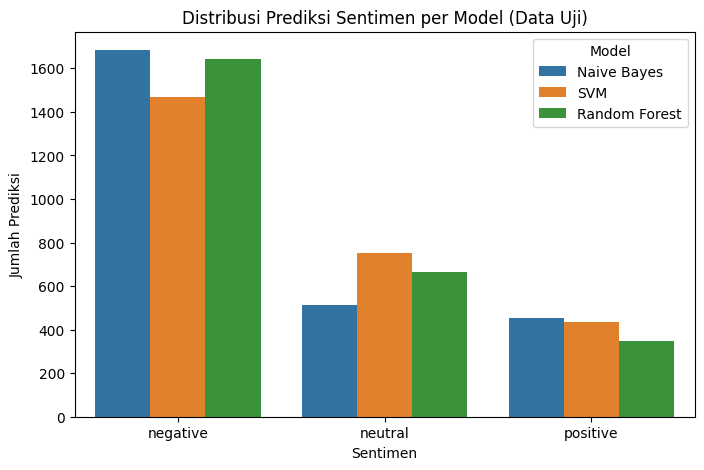

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np

# ===== 1. Load kembali objek dari folder =====
folder_path = "/content/drive/MyDrive/Skripsi/SMOTE_Full"  # ubah sesuai kebutuhan

label_encoder = joblib.load(f"{folder_path}/label_encoder.pkl")
vectorizer = joblib.load(f"{folder_path}/tfidf_vectorizer.pkl")

models = {
    "Naive Bayes": joblib.load(f"{folder_path}/naive_bayes.pkl"),
    "SVM": joblib.load(f"{folder_path}/svm.pkl"),
    "Random Forest": joblib.load(f"{folder_path}/random_forest.pkl")
}

# ===== 2. Load Data Uji =====
df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/labelrobertasudahconfidence.csv")

# Encode label sama seperti saat training
df["sentiment"] = label_encoder.transform(df["sentiment"])

# Split (pastikan random_state sama agar sesuai dengan training awal)
from sklearn.model_selection import train_test_split
X = df["clean_text"]
y = df["sentiment"]

_, X_test_text, _, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Transform dengan TF-IDF (fit sudah dilakukan sebelumnya saat training)
X_test_vec = vectorizer.transform(X_test_text)

# ===== 3. Prediksi Data Uji & Simpan Distribusi =====
test_pred_dist = []

for model_name, model in models.items():
    y_pred_test = model.predict(X_test_vec)

    unique, counts = np.unique(y_pred_test, return_counts=True)
    for cls, count in zip(unique, counts):
        test_pred_dist.append({
            "Model": model_name,
            "Sentimen": label_encoder.inverse_transform([cls])[0],
            "Jumlah": count
        })

# ===== 4. Visualisasi Grouped Bar Chart =====
test_pred_df = pd.DataFrame(test_pred_dist)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=test_pred_df,
    x="Sentimen",
    y="Jumlah",
    hue="Model",
    estimator=sum,
    errorbar=None
)
plt.title("Distribusi Prediksi Sentimen per Model (Data Uji)")
plt.ylabel("Jumlah Prediksi")
plt.xlabel("Sentimen")
plt.legend(title="Model")
plt.show()

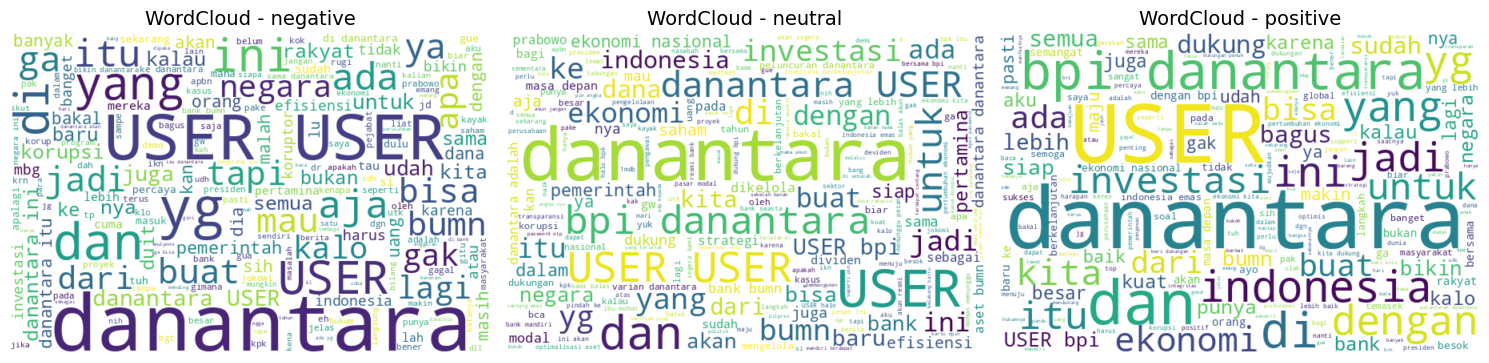

In [ ]:
# ===== 1. Import Library =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib
from wordcloud import WordCloud

# ===== 2. Load kembali objek dari folder =====
folder_path = "/content/drive/MyDrive/Skripsi/SMOTE_Latih"  # ubah sesuai kebutuhan

label_encoder = joblib.load(f"{folder_path}/label_encoder.pkl")
vectorizer = joblib.load(f"{folder_path}/tfidf_vectorizer.pkl")

# ===== 3. Load Dataset =====
df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/labelrobertasudahconfidence.csv")

# Encode label sama seperti saat training
df["sentiment"] = label_encoder.transform(df["sentiment"])

# Split dataset (pastikan random_state sama dengan training awal)
X = df["clean_text"]
y = df["sentiment"]

_, X_test_text, _, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===== 4. Buat WordCloud Per Kelas =====
class_texts = {}
for cls in np.unique(y_test):
    class_name = label_encoder.inverse_transform([cls])[0]  # ubah angka ke label
    text_joined = " ".join(X_test_text[y_test == cls])
    class_texts[class_name] = text_joined

# ===== 5. Visualisasi WordCloud =====
plt.figure(figsize=(15, 8))

for i, (class_name, text) in enumerate(class_texts.items(), 1):
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap="viridis",
        max_words=200
    ).generate(text)

    plt.subplot(1, len(class_texts), i)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {class_name}", fontsize=14)

plt.tight_layout()
plt.show()
